<a href="https://colab.research.google.com/github/2003UJAN/Laryngeal-Cancer-Few-Shot-Learning-XAI/blob/main/Laryngeal_Cancer_XAI_Normal_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pytorch_metric_learning

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinu

In [2]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 79.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.2-py3-none-any.whl size=38334 sha256=d247882da6389141e9ddd846ba12831ab00d8900c6d64a4cfc386906fb863e1d
  Stored in directory: /root/.cache/pip/wheels/b4/68/bb/d10381e86dc0de1c9354bce3d86bffcd247305058c40ce2e55
Successfully built grad-cam


In [3]:
import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from pytorch_metric_learning import losses
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [4]:
zip_path = 'archive.zip'
extract_path = '.'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [5]:
dataset_path = os.path.join(extract_path, 'laryngeal dataset', 'laryngeal dataset')

In [6]:
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])

In [7]:
train_data = datasets.ImageFolder(root=os.path.join(dataset_path, 'FOLD 1'), transform=transform)
val_data = datasets.ImageFolder(root=os.path.join(dataset_path, 'FOLD 2'), transform=transform)
test_data = datasets.ImageFolder(root=os.path.join(dataset_path, 'FOLD 3'), transform=transform)

In [8]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [9]:
class PrototypicalNetwork(nn.Module):
    def __init__(self, embedding_dim):
        super(PrototypicalNetwork, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(128*23*23, embedding_dim)
        )

    def forward(self, x):
        return self.encoder(x)

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [11]:
embedding_dim = 64
model = PrototypicalNetwork(embedding_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = losses.TripletMarginLoss(margin=1.0)

In [12]:
for epoch in range(40):
    model.train()
    train_loss = 0
    train_acc = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        embeddings = model(images)
        loss = criterion(embeddings, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_preds = embeddings.argmax(dim=1)
        train_acc += accuracy_score(labels.cpu(), train_preds.cpu())

    model.eval()
    val_loss = 0
    val_acc = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            embeddings = model(images)
            loss = criterion(embeddings, labels)
            val_loss += loss.item()
            val_preds = embeddings.argmax(dim=1)
            val_acc += accuracy_score(labels.cpu(), val_preds.cpu())

    print(f'Epoch {epoch+1}, Train Loss: {train_loss/len(train_loader)}, Train Accuracy: {train_acc/len(train_loader)}')
    print(f'Epoch {epoch+1}, Validation Loss: {val_loss/len(val_loader)}, Validation Accuracy: {val_acc/len(val_loader)}')

model.eval()
test_acc = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        embeddings = model(images)
        test_preds = embeddings.argmax(dim=1)
        test_acc += accuracy_score(labels.cpu(), test_preds.cpu())

print(f'Test Accuracy: {test_acc/len(test_loader)}')

Epoch 1, Train Loss: 0.8899990575654166, Train Accuracy: 0.0
Epoch 1, Validation Loss: 0.19493767193385533, Validation Accuracy: 0.0
Epoch 2, Train Loss: 0.9763924522059304, Train Accuracy: 0.0
Epoch 2, Validation Loss: 0.18941800509180343, Validation Accuracy: 0.0
Epoch 3, Train Loss: 0.9021216034889221, Train Accuracy: 0.0
Epoch 3, Validation Loss: 0.22328123450279236, Validation Accuracy: 0.0
Epoch 4, Train Loss: 0.9364793726376125, Train Accuracy: 0.0
Epoch 4, Validation Loss: 0.1936770464692797, Validation Accuracy: 0.0
Epoch 5, Train Loss: 0.8968722990580967, Train Accuracy: 0.0
Epoch 5, Validation Loss: 0.21532155786241805, Validation Accuracy: 0.0
Epoch 6, Train Loss: 0.8616421691008976, Train Accuracy: 0.017857142857142856
Epoch 6, Validation Loss: 0.14847309248788015, Validation Accuracy: 0.004464285714285714
Epoch 7, Train Loss: 0.8295185310500008, Train Accuracy: 0.008928571428571428
Epoch 7, Validation Loss: 0.12852455888475692, Validation Accuracy: 0.0
Epoch 8, Train Loss

In [13]:
def generate_gradcam(model, image, target_layer):
    if image.shape[0] != model.encoder[0].weight.shape[1]:
        image = image.repeat(model.encoder[0].weight.shape[1], 1, 1)
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=image.unsqueeze(0))[0, :]
    image = image.permute(1, 2, 0).cpu().numpy()
    cam_image = show_cam_on_image(image, grayscale_cam, use_rgb=True)
    return cam_image

In [14]:
test_iter = iter(test_loader)
images, labels = next(test_iter)
image = images[0].to(device)

In [15]:
target_layer = model.encoder[-3]

In [16]:
cam_image = generate_gradcam(model, image, target_layer)

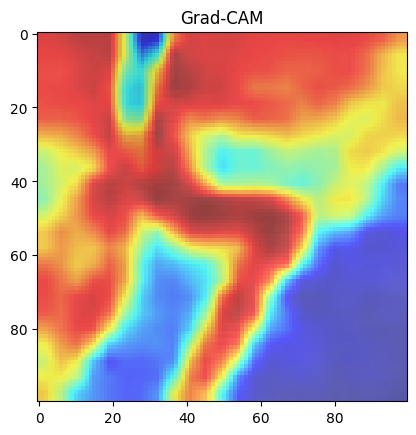

In [17]:
plt.imshow(cam_image)
plt.title('Grad-CAM')
plt.show()